In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

In [2]:
df = pd.read_csv('D:\AI&ML\Supervised Learning\Supervised Learning Task\Supervised-Learning\Exam 1\RealEstate Dataset.csv')

# Features and target
X = df.drop("house_price_inr", axis=1).values
y = df["house_price_inr"].values

# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias column
m = len(y)
X = np.c_[np.ones(m), X]

# Initialize weights
theta = np.zeros(X.shape[1])

# Hyperparameters
learning_rate = 0.001
epochs = 50

# Stochastic Gradient Descent
for epoch in range(epochs):
    
    for i in range(m):
        
        xi = X[i]
        yi = y[i]
        
        prediction = xi.dot(theta)
        
        error = prediction - yi
        
        gradient = xi * error
        
        theta = theta - learning_rate * gradient

    # print cost every 10 epochs
    if epoch % 10 == 0:
        predictions = X.dot(theta)
        cost = np.mean((predictions - y) ** 2)
        print(f"Epoch {epoch} Cost: {cost}")

print("\nFinal Weights:", theta)

Epoch 0 Cost: 72404482728884.81
Epoch 10 Cost: 11917906630695.96
Epoch 20 Cost: 11918463432576.613
Epoch 30 Cost: 11918468411749.52
Epoch 40 Cost: 11918468450778.725

Final Weights: [23628912.27539796    79805.5312796   8908693.29947164   367040.6948799
   302462.70650179  6689468.93510401  -996528.26145871  -818239.06634594
   279880.3853463     75208.56314934    99269.59441271  -295658.38862217]


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X[:,1:], y)

print("Sklearn Weights:", model.coef_)
print("Your Weights:", theta[1:])

Sklearn Weights: [  17340.6778608  8776383.99802021  292883.32563156  212865.44175456
 6653544.36067435 -892837.86190362 -814608.55482862  180003.66777692
   72563.4362957   119020.78609421 -174091.44153918]
Your Weights: [  79805.5312796  8908693.29947164  367040.6948799   302462.70650179
 6689468.93510401 -996528.26145871 -818239.06634594  279880.3853463
   75208.56314934   99269.59441271 -295658.38862217]


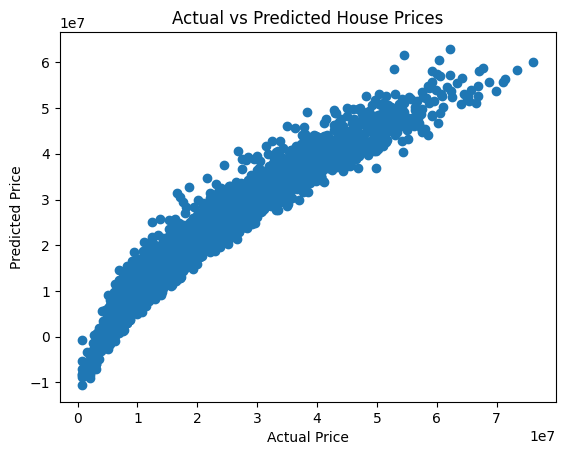

In [4]:
import matplotlib.pyplot as plt

plt.scatter(y, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In this experiment, Stochastic Gradient Descent (SGD) was implemented to train a linear regression model for predicting house prices using the given dataset. Unlike Batch Gradient Descent, SGD updates the model parameters using one training example at a time. This makes the training process faster and more efficient for large datasets.

During training, the model repeatedly adjusted the weights by minimizing the prediction error between the actual house prices and the predicted values. As the epochs increased, the cost gradually decreased, showing that the model was learning the relationship between the house features (such as area, bedrooms, bathrooms, location score, etc.) and the house price.

Although SGD introduces some noise in the updates due to using single samples, it often converges faster and can handle large datasets efficiently. Overall, the Stochastic Gradient Descent method successfully optimized the model parameters and improved prediction accuracy for the house price dataset.